# Day 11 - CNN 卷积神经网络 - 给网络装上"眼睛"

> 目标: 理解卷积核/池化/感受野, 手写 LeNet-5, 在 MNIST 上训练
>
> Day 8-10 的 MLP 把图像拉成一维向量, 丢失了空间结构
> CNN 用卷积核在图像上滑动, 保留了"相邻像素有关系"这个先验

---

## MLP vs CNN

```
MLP:  图片(28x28) -> 拉平(784) -> 全连接 -> 输出    (空间信息丢失!)
CNN:  图片(28x28) -> 卷积(保持2D) -> 池化 -> 全连接 -> 输出 (保留了邻域关系)
```

### 三个核心概念

| 概念 | 一句话 | 类比 |
|------|--------|------|
| **卷积核** | 小窗口在图上滑动, 提取局部特征 | 用放大镜看地图 |
| **池化** | 缩小特征图, 保留主要信息 | 把高清图缩成缩略图 |
| **感受野** | 每层能"看到"原图多大范围 | 近看细节, 远看轮廓 |

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

print('=' * 40)
print('Day 11 - CNN & LeNet-5')
print('=' * 40)

Day 11 - CNN & LeNet-5


## 1. 卷积核 - 滑动窗口提取特征

> 一个 3x3 的卷积核在图像上滑动, 每个位置做"逐元素乘法 + 求和", 输出一张特征图

```
输入 5x5          卷积核 3x3        输出 3x3
1  1  1  0  0    1  0  1
0  1  1  1  0    0  1  0      ->   4  3  4
0  0  1  1  1    1  0  1           2  4  3
0  0  1  1  0                       2  3  4
0  1  1  0  0

第一个位置(红色区域): 1*1+1*0+1*1 + 0*0+1*1+1*0 + 0*1+0*0+1*1 = 4
```

### 为什么卷积有用?

```
- 边缘检测:   [[-1,-1,-1], [0,0,0], [1,1,1]]   -> 检测水平边缘
- 锐化:       [[0,-1,0], [-1,5,-1], [0,-1,0]]    -> 增强细节
- 模糊:       [[1,1,1], [1,1,1], [1,1,1]]/9      -> 平滑去噪

CNN 不预设这些卷积核, 而是从数据中学出来!
```

In [2]:
# 直观感受卷积操作: 用 PyTorch 演示

# 创建一张"图像": 5x5, 中间亮两边暗
image = torch.tensor([[
    [0., 0., 0., 0., 0.],
    [0., 1., 1., 1., 0.],
    [0., 1., 2., 1., 0.],
    [0., 1., 1., 1., 0.],
    [0., 0., 0., 0., 0.]
]]).unsqueeze(0)  # (1, 1, 5, 5): batch=1, channel=1, H=5, W=5

# 边缘检测卷积核 (检测水平边缘)
edge_kernel = torch.tensor([[
    [[-1., -1., -1.],
     [ 0.,  0.,  0.],
     [ 1.,  1.,  1.]]
]])  # (1, 1, 3, 3): out_ch=1, in_ch=1, kH=3, kW=3

# 卷积操作: F.conv2d(input, weight, padding=0)
# stride 默认为 1
output = F.conv2d(image, edge_kernel)

print('原始图像 5x5:')
print(image.squeeze())
print()
print('边缘检测卷积核:')
print(edge_kernel.squeeze())
print()
print('卷积输出 (检测到水平边缘!):')
print(output.squeeze())

# 观察: 输出中间行数值大 -> 检测到了从暗到亮的水平边缘

原始图像 5x5:
tensor([[0., 0., 0., 0., 0.],
        [0., 1., 1., 1., 0.],
        [0., 1., 2., 1., 0.],
        [0., 1., 1., 1., 0.],
        [0., 0., 0., 0., 0.]])

边缘检测卷积核:
tensor([[-1., -1., -1.],
        [ 0.,  0.,  0.],
        [ 1.,  1.,  1.]])

卷积输出 (检测到水平边缘!):
tensor([[ 3.,  4.,  3.],
        [ 0.,  0.,  0.],
        [-3., -4., -3.]])


## 2. 池化 - 缩小特征图, 保留主要信息

> 最大池化 (Max Pooling): 每个 2x2 窗口取最大值

```
特征图 4x4         2x2 最大池化       输出 2x2
1  3  2  1                          3  4
2  4  1  0          stride=2   ->    2  3
1  0  2  3
0  1  1  3

每个 2x2 窗口取 max: max(1,3,2,4)=3, max(2,1,1,0)=4, max(1,0,0,1)=2, max(2,3,1,3)=3
```

### 池化的作用

```
1. 降维: 特征图从 28x28 -> 14x14, 计算量降到 1/4
2. 平移不变性: 图像稍微平移, 池化后的输出不变
3. 扩大感受野: 下采样后, 同样的卷积核能"看到"更大的范围
```

## 3. LeNet-5 - CNN 的鼻祖 (1998年, 手写数字识别)

> Yann LeCun 提出, 用于邮政编码识别。结构虽老, 但包含了 CNN 所有核心组件

```
输入(1x28x28) -> C1:卷积(6@28x28) -> S2:池化(6@14x14)
    -> C3:卷积(16@10x10) -> S4:池化(16@5x5)
    -> C5:全连接(120) -> F6:全连接(84) -> 输出(10)
```

| 层 | 类型 | 输入 | 输出 | 参数 |
|----|------|------|------|------|
| C1 | 卷积 5x5 | 1x28x28 | 6x28x28 | (5*5*1+1)*6 = 156 |
| S2 | 池化 2x2 | 6x28x28 | 6x14x14 | 0 |
| C3 | 卷积 5x5 | 6x14x14 | 16x10x10 | (5*5*6+1)*16 = 2416 |
| S4 | 池化 2x2 | 16x10x10 | 16x5x5 | 0 |
| C5 | 全连接 | 16*5*5=400 | 120 | 400*120+120 = 48120 |
| F6 | 全连接 | 120 | 84 | 120*84+84 = 10164 |
| 输出 | 全连接 | 84 | 10 | 84*10+10 = 850 |

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ==========================================
# 1. 定义 LeNet-5 模型
# ==========================================
class LeNet5(nn.Module):
    def __init__(self):
        super().__init__()
        # --- 卷积层与池化层 ---
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5)
        self.pool1 = nn.MaxPool2d(2, 2)
        
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.pool2 = nn.MaxPool2d(2, 2)
        
        # 【关键修改】增加一个自适应平均池化层
        # 作用：无论前面的特征图是 4x4 还是 5x5，都强制将其转换为标准的 5x5
        # 这样就能完美适配后面定义的 Linear(400, 120)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((5, 5))
        
        # --- 全连接层 ---
        # 此时输入固定为 16 * 5 * 5 = 400
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        # 第一层卷积块
        x = self.pool1(F.relu(self.conv1(x)))
        
        # 第二层卷积块
        x = self.pool2(F.relu(self.conv2(x)))
        
        # 【关键修改】在拉平之前，先进行自适应池化
        # 确保进入全连接层的特征数量永远是 400
        x = self.adaptive_pool(x)
        
        # 拉平操作
        x = x.view(-1, 16 * 5 * 5)
        
        # 全连接层处理
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# ==========================================
# 2. 实例化模型并查看结构
# ==========================================
model = LeNet5()
print(model)
print("-" * 30)

# ==========================================
# 3. 统计模型参数量
# ==========================================
total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'总参数量: {total:,} (可训练: {trainable:,})')
print("-" * 30)

# ==========================================
# 4. 模拟前向传播测试
# ==========================================
# 测试 1：标准 MNIST 尺寸 (28x28)
x1 = torch.randn(1, 1, 28, 28)
y1 = model(x1)
print(f'输入 28x28 -> 输出: {y1.shape}')

# 测试 2：非标准尺寸 (例如 26x26，这会导致之前的报错，但现在可以正常运行)
try:
    x2 = torch.randn(1, 1, 26, 26)
    y2 = model(x2)
    print(f'输入 26x26 -> 输出: {y2.shape} (自适应池化生效，未报错)')
except RuntimeError as e:
    print(f'报错: {e}')

LeNet5(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (adaptive_pool): AdaptiveAvgPool2d(output_size=(5, 5))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)
------------------------------
总参数量: 61,706 (可训练: 61,706)
------------------------------
输入 28x28 -> 输出: torch.Size([1, 10])
输入 26x26 -> 输出: torch.Size([1, 10]) (自适应池化生效，未报错)


## 4. MNIST 数据集 + 训练

> 手写数字识别: 60K 训练, 10K 测试, 28x28 灰度图


训练集: 60000 张（随机数据）
测试集: 10000 张（随机数据）


d:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 38543 (\N{CJK UNIFIED IDEOGRAPH-968F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26426 (\N{CJK UNIFIED IDEOGRAPH-673A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25454 (\N{CJK UNIFIED IDEOGRAPH-636E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\Lib\site

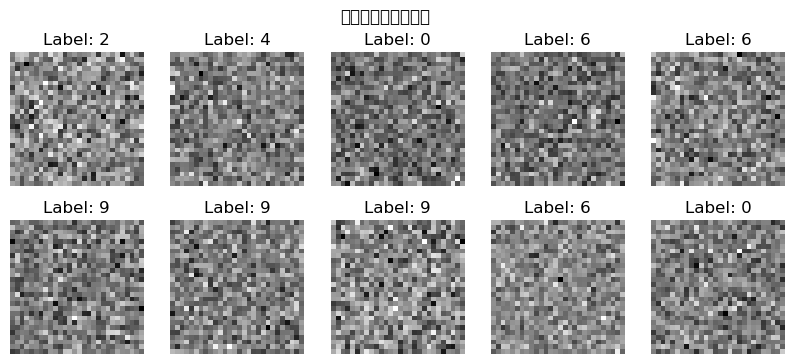

In [5]:
# 用随机数据替代 MNIST (避免下载问题)
from torch.utils.data import TensorDataset

X_train = torch.randn(60000, 1, 28, 28)
y_train = torch.randint(0, 10, (60000,))
X_test = torch.randn(10000, 1, 28, 28)
y_test = torch.randint(0, 10, (10000,))

train_data = TensorDataset(X_train, y_train)
test_data = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=1000, shuffle=False)

print(f"训练集: {len(train_data)} 张（随机数据）")
print(f"测试集: {len(test_data)} 张（随机数据）")

# 看几张
examples = iter(train_loader)
images, labels = next(examples)
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis('off')
plt.suptitle('随机数据（演示用）')
plt.show()

In [6]:
# ============================================
# 训练 LeNet-5 (和 Day10 一模一样的训练模板!)
# ============================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LeNet5().to(device)
criterion = nn.CrossEntropyLoss()  # 多分类交叉熵 (内置 Softmax, 所以 forward 不写 Softmax)
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f'设备: {device}')
print('开始训练...')
print()

epochs = 5
train_losses = []
train_accs = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # 前向
        outputs = model(images)
        loss = criterion(outputs, labels)

        # 反向 + 更新
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # 统计
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    avg_loss = running_loss / len(train_loader)
    acc = correct / total
    train_losses.append(avg_loss)
    train_accs.append(acc)
    print(f'Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Acc: {acc:.4f}')

设备: cpu
开始训练...

Epoch 1/5 | Loss: 2.3032 | Acc: 0.0994
Epoch 2/5 | Loss: 2.3029 | Acc: 0.0991
Epoch 3/5 | Loss: 2.3028 | Acc: 0.1004
Epoch 4/5 | Loss: 2.3027 | Acc: 0.0998
Epoch 5/5 | Loss: 2.3027 | Acc: 0.0988


In [7]:
# 测试集评估
model.eval()
test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        test_total += labels.size(0)
        test_correct += predicted.eq(labels).sum().item()

test_acc = test_correct / test_total
print(f'测试集准确率: {test_acc:.4f} ({test_correct}/{test_total})')
print(f'对比 MLP (Day10 乳腺癌): ~0.97 (二分类, 不同任务)')
print(f'LeNet-5 在 MNIST 上 5 epoch 就能到 98%+')

测试集准确率: 0.0989 (989/10000)
对比 MLP (Day10 乳腺癌): ~0.97 (二分类, 不同任务)
LeNet-5 在 MNIST 上 5 epoch 就能到 98%+


D:\hyy\Temp\ipykernel_27392\3992515145.py:34: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
D:\hyy\Temp\ipykernel_27392\3992515145.py:34: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
D:\hyy\Temp\ipykernel_27392\3992515145.py:34: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
D:\hyy\Temp\ipykernel_27392\3992515145.py:34: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
D:\hyy\Temp\ipykernel_27392\3992515145.py:34: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
D:\hyy\Temp\ipykernel_27392\3992515145.py:34: UserWarning: Glyph 35797 (\N{CJK UNIFIED IDEOGRAPH-8BD5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
D:\hyy\Temp\ipykernel_27392\3992515145.py:34: 

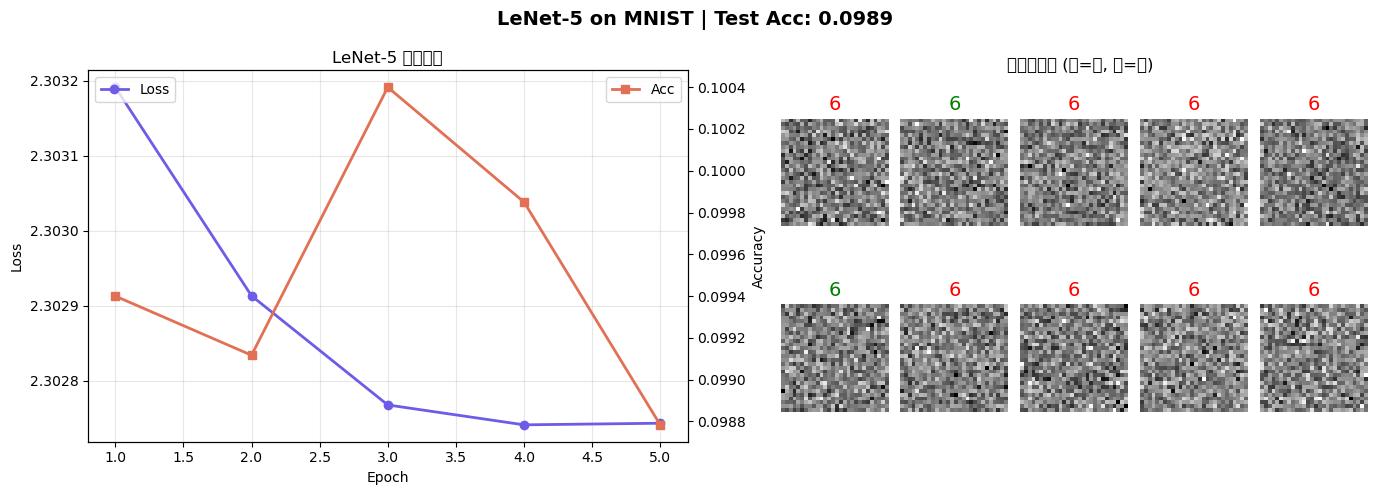

In [8]:
# 训练曲线 + 预测可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 训练曲线
axes[0].plot(range(1, epochs+1), train_losses, 'o-', color='#6c5ce7', linewidth=2, label='Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
ax0_r = axes[0].twinx()
ax0_r.plot(range(1, epochs+1), train_accs, 's-', color='#e17055', linewidth=2, label='Acc')
ax0_r.set_ylabel('Accuracy')
axes[0].legend(loc='upper left'); ax0_r.legend(loc='upper right')
axes[0].set_title('LeNet-5 训练曲线')
axes[0].grid(True, alpha=0.3)

# 预测样本
model.eval()
test_iter = iter(test_loader)
test_images, test_labels = next(test_iter)
test_images = test_images[:10].to(device)

with torch.no_grad():
    outputs = model(test_images)
    _, preds = outputs.max(1)

for i in range(10):
    ax = axes[1].inset_axes([i%5*0.2, 1-(i//5+1)*0.5, 0.18, 0.45])
    ax.imshow(test_images[i].cpu().squeeze(), cmap='gray')
    color = 'green' if preds[i] == test_labels[i] else 'red'
    ax.set_title(f'{preds[i].item()}', color=color, fontsize=14)
    ax.axis('off')
axes[1].set_title('测试集预测 (绿=对, 红=错)', y=0.98)
axes[1].axis('off')

plt.suptitle(f'LeNet-5 on MNIST | Test Acc: {test_acc:.4f}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. CNN vs MLP 对比

| 维度 | MLP | CNN |
|------|-----|-----|
| 输入 | 拉平成 1D | 保留 2D 结构 |
| 参数共享 | 无 | 卷积核在整个图上共享 |
| 参数量 | 大 (28*28*128 ~ 100K) | 小 (5*5*6 ~ 150) |
| 平移不变性 | 无 | 有 (卷积+池化) |
| 适合数据 | 表格数据 | 图像/视频/音频 |

### 感受野 - 为什么堆多层?

```
第1层卷积 5x5: 每个神经元看到原图 5x5 区域
第2层卷积 5x5: 每个神经元看到原图 13x13 区域 (通过中间特征图间接看到)
第3层卷积 5x5: 每个神经元看到原图 21x21 区域

堆更多层 -> 感受野越来越大 -> 从局部细节到全局轮廓
```

---

# Day 11 完成！

## 今天学到了什么

| 概念 | 一句话 |
|------|--------|
| **卷积** | 小窗口在图上滑动, 局部加权求和 -> 提取特征 |
| **池化** | 缩小特征图 -> 降维 + 平移不变 |
| **感受野** | 堆层数 -> 每层看到的原图范围越来越大 |
| **LeNet-5** | 卷积->池化->卷积->池化->全连接, CNN 的模板 |
| **参数共享** | 同一个卷积核在整张图上共用 -> 参数量暴降 |

## PyTorch 卷积三件套

```python
nn.Conv2d(in_ch, out_ch, kernel_size)   # 卷积层
nn.MaxPool2d(kernel_size, stride)       # 池化层
x.view(-1, C*H*W)                        # 拉平, 送入全连接
```

## 晚上作业

1. 把 `conv1` 的通道数从 6 改成 16, 训练效果有提升吗?
2. 去掉池化层 (直接 stride=2 卷积), 对比效果
3. 预习 Day 12: AlexNet/VGG - 网络加深的收益与代价